# Lecture 4 — Exploring, Visualizing and Preprocessing Data

This notebook walks through a typical exploratory data analysis (EDA) and preprocessing workflow using the Palmer Penguins dataset.

The notebook covers:
1. **Exploring data numerically** — inspecting shape, types, summary statistics and value counts
2. **Exploring data visually** — pair plots, scatter plots, box plots and violin plots with Seaborn
3. **Preprocessing** — handling missing and faulty values, creating new features, and scaling data

The dataset is loaded directly from the Palmer Penguins GitHub repository.

**Credits:**

Created by Sippo Rossi for the course Python Programming for Business Intelligence at Hanken.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

## 2. Loading the data

We load the Palmer Penguins dataset directly from GitHub. The dataset contains measurements of three penguin species observed on islands in the Palmer Archipelago, Antarctica.

In [2]:
df = pd.read_csv(
    "https://github.com/allisonhorst/palmerpenguins/raw/5b5891f01b52ae26ad8cb9755ec93672f49328a8/data/penguins_size.csv"
)

## 3. Exploring the data numerically

### 3.1 First look at the data

Inspecting the first few rows confirms that the data loaded correctly and gives a quick overview of the columns.

In [3]:
df.head()

,species_short,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


### 3.2 Data types and summary statistics

`info()` shows column names, non-null counts and data types. `describe()` provides summary statistics for numeric columns.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species_short      344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [5]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### 3.3 Value counts

For categorical columns it is useful to check how many observations belong to each category.

In [6]:
# How many of each species are there?

df["species_short"].value_counts()

species_short
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [7]:
# How many of each species live on each island?

cols = ["species_short", "island"] # Note, this could also be placed inside the code below as is done in the next example

df[cols].value_counts()

species_short  island   
Gentoo         Biscoe       124
Chinstrap      Dream         68
Adelie         Dream         56
               Torgersen     52
               Biscoe        44
Name: count, dtype: int64

In [8]:
# How many females and males are there in each species?

df[["species_short", "sex"]].value_counts()

species_short  sex   
Adelie         FEMALE    73
               MALE      73
Gentoo         MALE      61
               FEMALE    58
Chinstrap      FEMALE    34
               MALE      34
Gentoo         .          1
Name: count, dtype: int64

Notice that there is a Gentoo penguin with the sex recorded as `"."` instead of `MALE` or `FEMALE`. This is a data quality issue that we will fix during preprocessing.

### 3.4 Checking for missing values

In [9]:
# Count missing values per column

df.isna().sum()

species_short         0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [10]:
# Display rows that contain at least one missing value

df[df.isnull().any(axis=1)]

,species_short,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


## 4. Exploring data visually

Visual inspection is an important part of EDA. Summary statistics alone can be deceiving, as very different datasets can share identical numeric summaries. Plotting the data reveals patterns, clusters and outliers that numbers alone cannot show.

### 4.1 Pair plot

A pair plot shows scatter plots for every pair of numeric variables and distributions on the diagonal. Colouring by species makes it easy to see whether the species form distinct clusters.

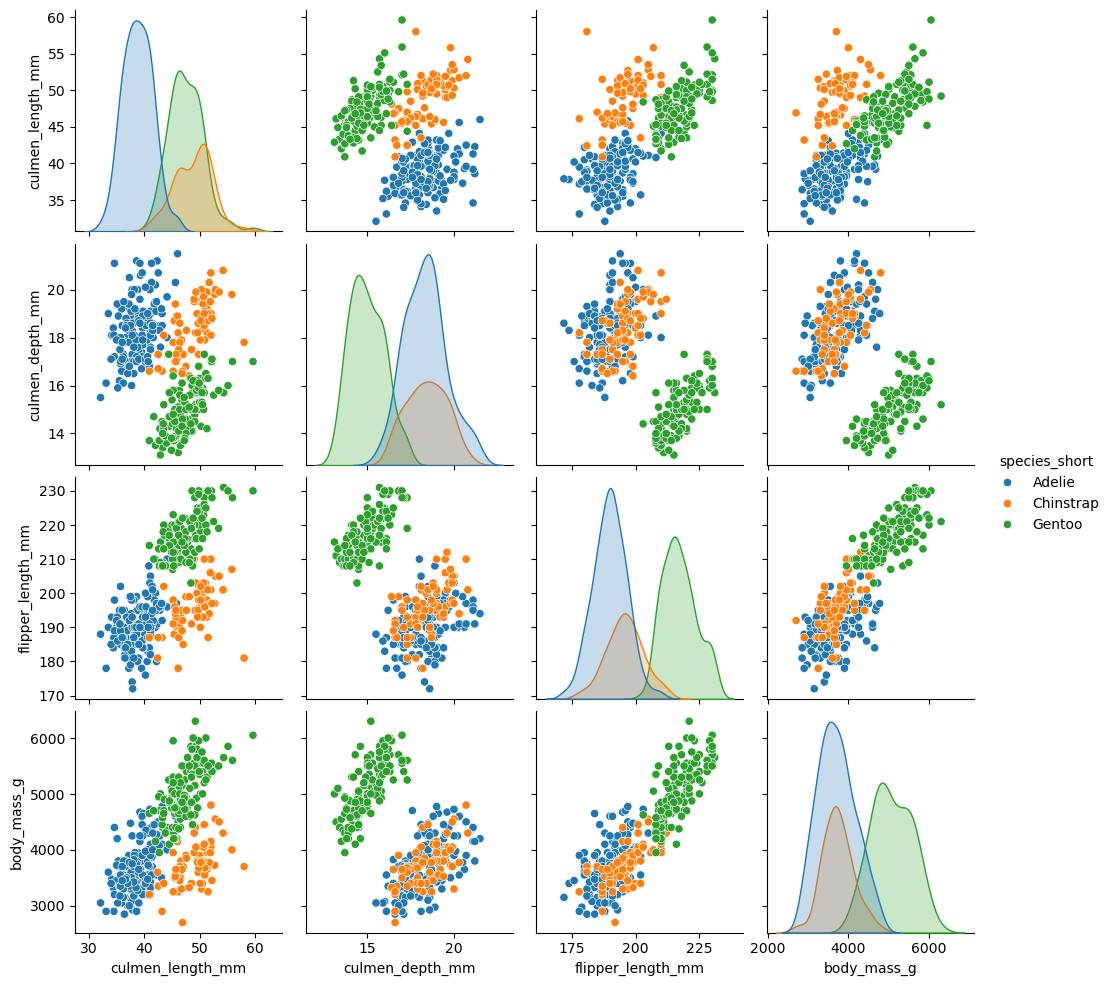

In [11]:
sns.pairplot(df, hue="species_short")

Several combinations of features, such as culmen depth and culmen length, separate the species quite clearly.

### 4.2 Box plot

Box plots show the distribution of a numeric variable across categories. They highlight the median, interquartile range and potential outliers.

<Axes: xlabel='species_short', ylabel='body_mass_g'>

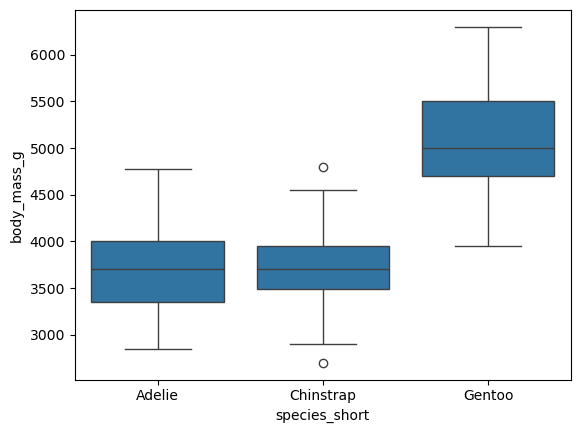

In [12]:
sns.boxplot(x="species_short", y="body_mass_g", data=df)

Gentoo penguins are clearly heavier than the other two species. Chinstrap has a few outliers in body mass.

<Axes: xlabel='species_short', ylabel='flipper_length_mm'>

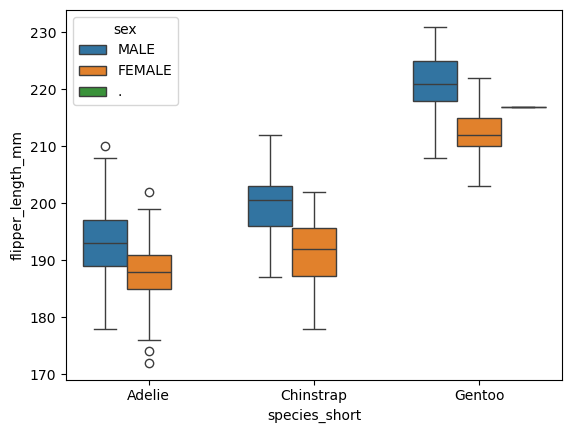

In [13]:
sns.boxplot(x="species_short", y="flipper_length_mm", hue="sex", data=df)

## 5. Preprocessing

Most real-world data requires some cleaning before it is ready for analysis. Common issues include missing values, faulty entries and inconsistent data types.

### 5.1 Fixing faulty data

We already noticed that one penguin has `"."` as its sex value. We replace it with `NaN` so it is treated consistently as a missing value.

In [14]:
df = df.replace('.', np.nan)

# Verify the fix
df[["species_short", "sex"]].value_counts()

species_short  sex   
Adelie         FEMALE    73
               MALE      73
Gentoo         MALE      61
               FEMALE    58
Chinstrap      FEMALE    34
               MALE      34
Name: count, dtype: int64

### 5.2 Handling missing values

There are two main strategies for dealing with missing data: removing the rows or imputing (filling in) the missing values.

Removing rows is simpler and less risky, but it can shrink the dataset or introduce bias if the missingness is not random. Imputing preserves dataset size but introduces estimated values.

In this case the two rows missing almost all measurements are difficult to impute reliably, because the physical measurements likely depend on sex, and sex is also missing for those rows. We therefore drop all rows with any missing value.

In [15]:
df = df.dropna()

print("Shape after dropping missing values:", df.shape)

Shape after dropping missing values: (333, 7)


### 5.3 Creating new features

Sometimes it is useful to combine existing features into a new one. A ratio can capture the relationship between two measurements in a single number.

Here we create a culmen ratio (length divided by depth).

In [16]:
df["culmen_ratio"] = df["culmen_length_mm"] / df["culmen_depth_mm"]

df.head()

,species_short,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_ratio
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE,2.090909
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,2.270115
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,2.238889
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,1.901554
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE,1.907767


### 5.4 Standardization and scaling

When features have very different scales (e.g. body mass in grams vs. culmen length in millimetres), some statistical methods and machine learning algorithms can be negatively affected. Two common remedies are standardization and min-max scaling.

**Standardization** (z-score) transforms data so that the mean is 0 and the standard deviation is 1. **Min-max scaling** rescales data to the range 0 to 1.

In [17]:
# Standardize body_mass_g

scaler = StandardScaler()
df["body_mass_g"] = scaler.fit_transform(df[["body_mass_g"]])

df.head()

,species_short,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_ratio
0,Adelie,Torgersen,39.1,18.7,181.0,-0.568475,MALE,2.090909
1,Adelie,Torgersen,39.5,17.4,186.0,-0.506286,FEMALE,2.270115
2,Adelie,Torgersen,40.3,18.0,195.0,-1.190361,FEMALE,2.238889
4,Adelie,Torgersen,36.7,19.3,193.0,-0.941606,FEMALE,1.901554
5,Adelie,Torgersen,39.3,20.6,190.0,-0.692852,MALE,1.907767


In [18]:
# Scale flipper_length_mm to the range 0-1

scaler = MinMaxScaler()
# scaler = MinMaxScaler(feature_range=(0,100))    # You can also vary the scale, e.g. to be 0-100

df["flipper_length_mm"] = scaler.fit_transform(df[["flipper_length_mm"]])

df.head()

,species_short,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_ratio
0,Adelie,Torgersen,39.1,18.7,0.152542,-0.568475,MALE,2.090909
1,Adelie,Torgersen,39.5,17.4,0.237288,-0.506286,FEMALE,2.270115
2,Adelie,Torgersen,40.3,18.0,0.389831,-1.190361,FEMALE,2.238889
4,Adelie,Torgersen,36.7,19.3,0.355932,-0.941606,FEMALE,1.901554
5,Adelie,Torgersen,39.3,20.6,0.305085,-0.692852,MALE,1.907767


Note that after these transformations the original units no longer apply. The transformed values are useful for modelling but less intuitive to interpret on their own.

Below we can see the changes made by scaling to the summary statistics. For example, as expected, after scaling the flipper_length_mm, values are now from 0-1.

In [19]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,culmen_ratio
count,333.000000,333.000000,333.000000,3.330000e+02,333.000000
mean,43.992793,17.164865,0.490966,-1.707010e-16,2.607228
std,5.468668,1.969235,0.237555,1.001505e+00,0.495436
min,32.100000,13.100000,0.000000,-1.874435e+00,1.639810
25%,39.500000,15.600000,0.305085,-8.172292e-01,2.162651
50%,44.500000,17.300000,0.423729,-1.953432e-01,2.576531
75%,48.600000,18.700000,0.694915,7.063915e-01,3.096970
max,59.600000,21.500000,1.000000,2.603144e+00,3.612676
